# Linear Algebra & Geometry for Machine Learning

> **References:** Mathematics for Machine Learning (Deisenroth, Faisal, Ong) · Bishop – Pattern Recognition and Machine Learning · Iacopo Masi – Geometry of Linear Maps (Sapienza SMIA) · Hadrien Jean – ML Fundamentals

**Goal:** A concise, code-first overview of linear algebra — from the basics of matrices to eigendecomposition — written for students of Applied Mathematics and AI. Each section pairs rigorous definitions with NumPy implementations and an explicit bridge to where the concept appears in ML.

---
## Table of Contents
1. [Matrix](#1-matrix)
2. [Vector Spaces & Subspaces](#2-vector-spaces-subspaces)
3. [Basis & Rank](#3-basis-rank)
4. [Determinants](#4-determinants)
5. [Eigenvalues & Eigendecomposition](#5-eigenvalues-eigendecomposition)

---
## Why Linear Algebra?

In machine learning we never work with a single number in isolation. A single image is a matrix of pixel values. A dataset of 10,000 samples with 300 features is a $10000 \times 300$ matrix. The parameters of a neural network layer are a matrix. The operation of applying that layer to an input is matrix multiplication.

Linear algebra is the language that gives structure to all of this — vectors to hold data points, matrices to represent transformations, and decompositions to reveal the hidden geometry inside data.

---
# 1. Matrix

With $m, n \in \mathbb{N}$, a real-valued matrix $A$ is an $m \times n$ array of elements $a_{ij}$ with $i = 1, \dots, m$ (rows) and $j = 1, \dots, n$ (columns):

$$
A = \begin{pmatrix}
a_{11} & a_{12} & \cdots & a_{1n} \\
a_{21} & a_{22} & \cdots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{m1} & a_{m2} & \cdots & a_{mn}
\end{pmatrix}, \quad a_{ij} \in \mathbb{R}
$$

We write $A \in \mathbb{R}^{m \times n}$. When $m = 1$ the matrix is a **row vector**; when $n = 1$ it is a **column vector**.

> **ML Bridge:** In a supervised learning dataset, the feature matrix $X \in \mathbb{R}^{N \times D}$ has one row per sample and one column per feature.

In [ ]:
import numpy as np

# Three feature vectors (each sample has 4 features)
v1 = np.array([1,  2,  4, 67])
v2 = np.array([5,  8,  2, 45])
v3 = np.array([3,  1,  9, 12])

# Stack them as rows to form the feature matrix X (3 samples x 4 features)
X = np.array([v1, v2, v3])

print(f"Feature matrix X — shape {X.shape}:")
print(X)

## 1.1 Vectorization

It is sometimes useful to treat a matrix as a single long vector. The **vectorization** operator $\text{vec}(A)$ stacks the columns of $A$ one on top of the other:

$$
A = [\mathbf{a}_1 \mid \mathbf{a}_2 \mid \dots \mid \mathbf{a}_n] \in \mathbb{R}^{m \times n}
\quad \Longrightarrow \quad
\text{vec}(A) = \begin{bmatrix} \mathbf{a}_1 \\ \mathbf{a}_2 \\ \vdots \\ \mathbf{a}_n \end{bmatrix} \in \mathbb{R}^{mn}
$$

> **ML Bridge:** Every 28×28 grayscale image in MNIST is vectorized to a 784-dimensional input vector before being fed to a fully-connected network.

In [ ]:
import numpy as np

A = np.array([[1, 4],
              [2, 5],
              [3, 6]])  # shape (3, 2)

# Column-major (Fortran) order matches the mathematical definition of vec(A)
a_vec = A.flatten(order='F')

print(f"Original matrix A {A.shape}:\n{A}")
print(f"\nvec(A) — shape {a_vec.shape}:\n{a_vec}")

## 1.2 Matrix Addition and Multiplication

### Addition and Scalar Multiplication

For $A, B \in \mathbb{R}^{m \times n}$, addition is **element-wise**:

$$
(A + B)_{ij} = a_{ij} + b_{ij}
$$

Multiplying by a scalar $\lambda \in \mathbb{R}$ scales every element:

$$
(\lambda A)_{ij} = \lambda \, a_{ij}
$$

Both operations require identical dimensions.

---

### Matrix–Matrix Multiplication

For $A \in \mathbb{R}^{m \times n}$ and $B \in \mathbb{R}^{n \times p}$, the product $C = AB \in \mathbb{R}^{m \times p}$ is defined by:

$$
c_{ij} = \sum_{k=1}^{n} a_{ik} \, b_{kj}
$$

The inner dimensions must match ($n$ columns of $A$ = $n$ rows of $B$). Matrix multiplication is **not commutative**: $AB \neq BA$ in general.

> **ML Bridge:** A forward pass in a neural network is a sequence of matrix multiplications: $h = \sigma(Wx + b)$, where $W$ is the weight matrix.

In [ ]:
import numpy as np

# Definizione delle matrici
A = np.array([[1, 2, 3],
              [4, 5, 6]])   # Shape: (2, 3)

B = np.array([[7,  8],
              [9,  10],
              [11, 12]])    # Shape: (3, 2)

# 1. Prodotto C = A @ B
C = A @ B  # Risultato atteso: (2, 2)

# 2. Prodotto D = B @ A
D = B @ A  # Risultato atteso: (3, 3)

print(f"Shape di A: {A.shape}")
print(f"Shape di B: {B.shape}")
print("-" * 30)
print(f"A @ B (C) shape: {C.shape}")
print(C)
print(f"\nB @ A (D) shape: {D.shape}")
print(D)
print("-" * 30)

# Verifica della non-commutatività in modo sicuro
# Non usiamo np.allclose(C, D) perché fallirebbe a causa degli shape diversi
if C.shape != D.shape:
    print("Conclusion: A @ B != B @ A they have a different dimension!")
else:
    # Caso (raro) in cui gli shape sono uguali ma i valori diversi
    are_equal = np.allclose(C, D)
    print(f"A @ B == B @ A ? {are_equal}")

# Verifica manuale corretta del primo elemento c[0,0]
c00_manual = (A[0,0] * B[0,0]) + (A[0,1] * B[1,0]) + (A[0,2] * B[2,0])
print(f"\nVerify c[0,0]: {c00_manual} (NumPy dice: {C[0,0]})")

## 1.3 Matrices as Linear Maps

A matrix $A \in \mathbb{R}^{m \times n}$ defines a **linear map** $\Phi: \mathbb{R}^n \to \mathbb{R}^m$, $\mathbf{x} \mapsto A\mathbf{x}$. This map is linear because:

$$
A(\lambda \mathbf{x} + \mu \mathbf{y}) = \lambda A\mathbf{x} + \mu A\mathbf{y}, \quad \forall \lambda, \mu \in \mathbb{R}
$$

A classic example is the **2D rotation matrix** by angle $\theta$:

$$
R_\theta = \begin{bmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{bmatrix}
$$

> **ML Bridge:** Convolutional filters, attention scores, and affine transformations in generative models are all linear maps applied to vectors.

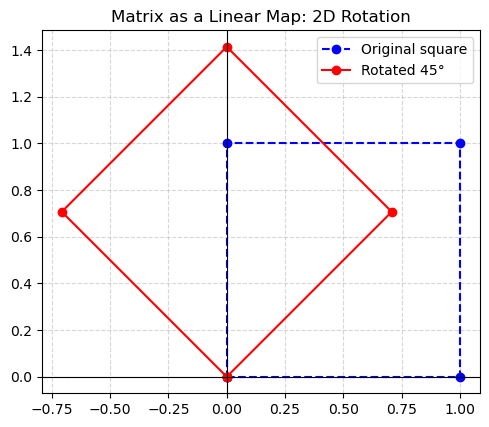

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Unit square corners (close the loop by repeating the first point)
points = np.array([[0, 1, 1, 0, 0],
                   [0, 0, 1, 1, 0]])

# Build a 45-degree rotation matrix
theta = np.radians(45)
c, s = np.cos(theta), np.sin(theta)
R = np.array([[c, -s],
              [s,  c]])

rotated = R @ points

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(points[0], points[1], 'b--o', label='Original square')
ax.plot(rotated[0], rotated[1], 'r-o',  label='Rotated 45°')
ax.axhline(0, color='k', linewidth=0.8)
ax.axvline(0, color='k', linewidth=0.8)
ax.set_aspect('equal')
ax.grid(True, linestyle='--', alpha=0.5)
ax.legend()
ax.set_title('Matrix as a Linear Map: 2D Rotation')
plt.tight_layout()
plt.show()

## 1.4 Transpose, Inverse, and Symmetric Matrices

### Transpose
The **transpose** $A^\top \in \mathbb{R}^{n \times m}$ of $A \in \mathbb{R}^{m \times n}$ swaps rows and columns:
$(A^\top)_{ij} = A_{ji}$.

Key property: $(AB)^\top = B^\top A^\top$

---

### Inverse
For a square matrix $A \in \mathbb{R}^{n \times n}$, the **inverse** $A^{-1}$ satisfies:
$$A A^{-1} = A^{-1} A = I_n$$

$A$ is invertible (non-singular) if and only if $\det(A) \neq 0$.

> **ML Bridge:** The closed-form solution to linear regression is $\hat{\theta} = (X^\top X)^{-1} X^\top y$ — the **Normal Equation**. In practice we avoid explicit inversion for numerical stability, but the formula is derived from it.

---

### Symmetric Matrices
A square matrix is **symmetric** if $A = A^\top$, i.e., $a_{ij} = a_{ji}$.

> **ML Bridge:** Covariance matrices and kernel (Gram) matrices are always symmetric. This has deep implications: symmetric matrices have real eigenvalues and orthogonal eigenvectors (Spectral Theorem).

In [ ]:
import numpy as np

A = np.array([[3, 1],
              [2, 4]], dtype=float)

print("A:\n", A)
print("\nA.T:\n", A.T)
print("\nA_inv:\n", np.linalg.inv(A))
print("\nA @ A_inv (should be I):\n", np.round(A @ np.linalg.inv(A), 10))

# Build a symmetric matrix
S = A.T @ A
print("\nS = A^T A (symmetric):\n", S)
print("S == S.T:", np.allclose(S, S.T))

---
# 2. Vector Spaces & Subspaces

## 2.1 Vector Space

A **real vector space** is a set $V$ equipped with two operations:
- **Addition** $+: V \times V \to V$
- **Scalar multiplication** $\cdot: \mathbb{R} \times V \to V$

satisfying the following axioms for all $\mathbf{x}, \mathbf{y}, \mathbf{z} \in V$ and $\lambda, \psi \in \mathbb{R}$:

| Axiom | Statement |
|---|---|
| Commutativity | $\mathbf{x} + \mathbf{y} = \mathbf{y} + \mathbf{x}$ |
| Associativity (addition) | $(\mathbf{x} + \mathbf{y}) + \mathbf{z} = \mathbf{x} + (\mathbf{y} + \mathbf{z})$ |
| Neutral element | $\exists\, \mathbf{0} \in V: \mathbf{x} + \mathbf{0} = \mathbf{x}$ |
| Inverse element | $\exists\, {-\mathbf{x}} \in V: \mathbf{x} + ({-\mathbf{x}}) = \mathbf{0}$ |
| Distributivity (scalar over vector sum) | $\lambda(\mathbf{x} + \mathbf{y}) = \lambda\mathbf{x} + \lambda\mathbf{y}$ |
| Distributivity (vector over scalar sum) | $(\lambda + \psi)\mathbf{x} = \lambda\mathbf{x} + \psi\mathbf{x}$ |
| Associativity (scalar multiplication) | $\lambda(\psi\mathbf{x}) = (\lambda\psi)\mathbf{x}$ |
| Neutral element (scalar) | $1 \cdot \mathbf{x} = \mathbf{x}$ |

The most familiar example is $\mathbb{R}^n$ with standard addition and scalar multiplication.

---

## 2.2 Vector Subspace

A non-empty subset $U \subseteq V$ is a **subspace** of $V$ if it is itself a vector space under the same operations. Since $U$ inherits most axioms from $V$, we only need to verify three conditions:

1. $\mathbf{0} \in U$ (contains the zero vector)
2. $\forall \lambda \in \mathbb{R},\, \mathbf{x} \in U \Rightarrow \lambda\mathbf{x} \in U$ (closed under scalar multiplication)
3. $\forall \mathbf{x}, \mathbf{y} \in U \Rightarrow \mathbf{x} + \mathbf{y} \in U$ (closed under addition)

Intuitively: a subspace is a "flat" structure through the origin that you can never escape by adding or scaling its vectors.

> **ML Bridge:** The **column space** (image) of a matrix $A$ is a subspace of $\mathbb{R}^m$. The **null space** (kernel) is a subspace of $\mathbb{R}^n$. Understanding these is key for analyzing when $Ax = b$ has solutions.

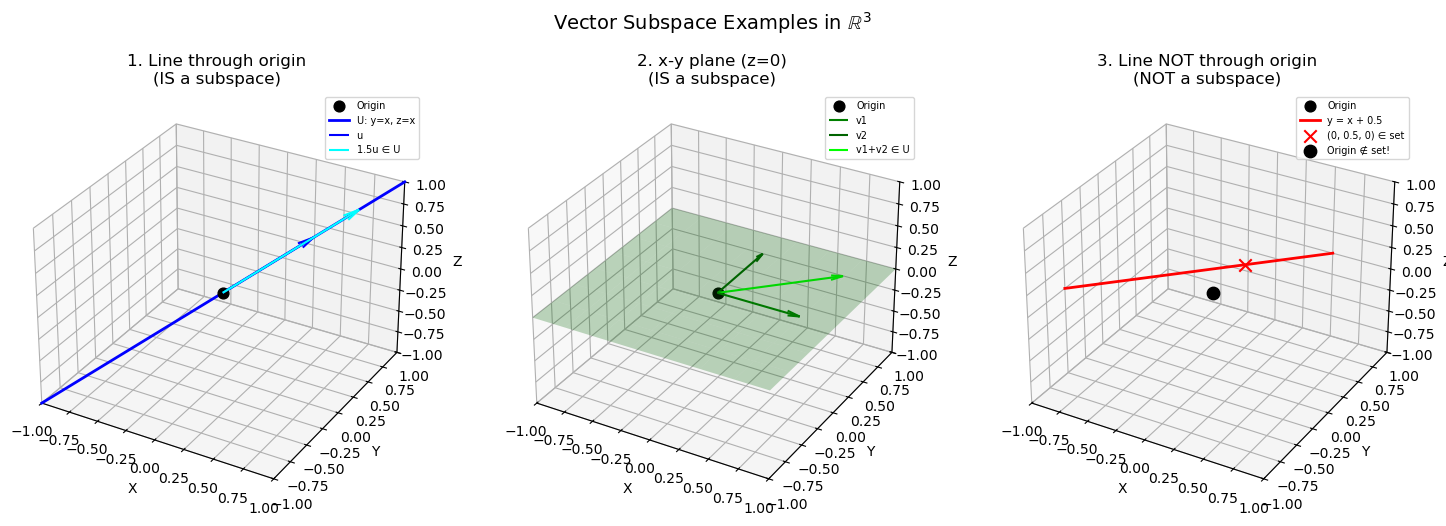

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(15, 5))

def setup(ax, title):
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_xlim(-1, 1); ax.set_ylim(-1, 1); ax.set_zlim(-1, 1)
    ax.scatter([0],[0],[0], color='black', s=60, zorder=5, label='Origin')

# --- Example 1: Line through the origin in R^3  (IS a subspace) ---
ax1 = fig.add_subplot(131, projection='3d')
setup(ax1, '1. Line through origin\n(IS a subspace)')
t = np.linspace(-1, 1, 100)
ax1.plot(t, t, t, 'b', lw=2, label='U: y=x, z=x')
u = np.array([0.5, 0.5, 0.5])
ax1.quiver(0,0,0, *u, color='blue', arrow_length_ratio=0.15, label='u')
ax1.quiver(0,0,0, *(1.5*u), color='cyan', arrow_length_ratio=0.1, label='1.5u ∈ U')
ax1.legend(fontsize=7)

# --- Example 2: The x-y plane in R^3  (IS a subspace) ---
ax2 = fig.add_subplot(132, projection='3d')
setup(ax2, '2. x-y plane (z=0)\n(IS a subspace)')
xx, yy = np.meshgrid(np.linspace(-1,1,8), np.linspace(-1,1,8))
ax2.plot_surface(xx, yy, xx*0, alpha=0.25, color='green')
v1 = np.array([0.7, 0.0, 0.0])
v2 = np.array([0.0, 0.7, 0.0])
ax2.quiver(0,0,0, *v1, color='green', arrow_length_ratio=0.15, label='v1')
ax2.quiver(0,0,0, *v2, color='darkgreen', arrow_length_ratio=0.15, label='v2')
ax2.quiver(0,0,0, *(v1+v2), color='lime', arrow_length_ratio=0.1, label='v1+v2 ∈ U')
ax2.legend(fontsize=7)

# --- Example 3: Affine line NOT through origin  (NOT a subspace) ---
ax3 = fig.add_subplot(133, projection='3d')
setup(ax3, '3. Line NOT through origin\n(NOT a subspace)')
t = np.linspace(-1, 0.5, 100)
ax3.plot(t, t + 0.5, t*0, 'r', lw=2, label='y = x + 0.5')
# Show 0 is not in the set
ax3.scatter([0],[0.5],[0], color='red', s=80, marker='x', label='(0, 0.5, 0) ∈ set')
ax3.scatter([0],[0],[0], color='black', s=80, label='Origin ∉ set!')
ax3.legend(fontsize=7)

plt.suptitle('Vector Subspace Examples in $\\mathbb{R}^3$', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# 3. Basis & Rank

## 3.1 Linear Independence and Span

A set of vectors $\{\mathbf{x}_1, \dots, \mathbf{x}_k\} \subseteq V$ is **linearly independent** if the only solution to
$$\lambda_1 \mathbf{x}_1 + \dots + \lambda_k \mathbf{x}_k = \mathbf{0}$$
is $\lambda_1 = \dots = \lambda_k = 0$. Intuitively: no vector in the set can be written as a combination of the others.

The **span** of $A = \{\mathbf{x}_1, \dots, \mathbf{x}_k\}$ is the set of all linear combinations:
$$\text{span}(A) = \left\{ \sum_{i=1}^k \lambda_i \mathbf{x}_i \;\middle|\; \lambda_i \in \mathbb{R} \right\}$$

---

## 3.2 Basis

A **basis** of a vector space $V$ is a set $B \subseteq V$ that is simultaneously:
- **linearly independent**, and
- a **generating set** (i.e., $\text{span}(B) = V$)

Equivalently, $B$ is a basis iff every $\mathbf{x} \in V$ has a **unique** representation as a linear combination of elements of $B$.

The **dimension** $\dim(V)$ is the number of vectors in any basis (all bases of the same space have the same cardinality).

---

## 3.3 Rank

The **rank** of a matrix $A \in \mathbb{R}^{m \times n}$ is the number of linearly independent columns (equivalently, rows):
$$\text{rk}(A) = \dim(\text{col}(A))$$

Key properties:
- $\text{rk}(A) = \text{rk}(A^\top)$ — column rank equals row rank
- $A \in \mathbb{R}^{n \times n}$ is invertible $\iff \text{rk}(A) = n$ (full rank)
- $\dim(\ker(A)) = n - \text{rk}(A)$ — **Rank–Nullity Theorem**
- $\text{rk}(A) \leq \min(m, n)$

> **ML Bridge:** A data matrix with rank $< D$ means features are linearly dependent — some features are redundant. Rank also determines the number of non-zero singular values in SVD, and the effective dimensionality of the data.

In [ ]:
import numpy as np

# --- Linear independence check ---
v1 = np.array([1, 0, 0])
v2 = np.array([0, 1, 0])
v3 = np.array([1, 1, 0])  # v3 = v1 + v2  → linearly dependent!

M_dep = np.column_stack([v1, v2, v3])
M_ind = np.column_stack([v1, v2, np.array([0, 0, 1])])  # full rank

print("=== Linear Dependence ===")
print(f"rank([v1|v2|v3]) = {np.linalg.matrix_rank(M_dep)}  (< 3, so dependent)")
print(f"rank([v1|v2|e3]) = {np.linalg.matrix_rank(M_ind)}  (= 3, so independent — a basis of R^3)")

print()

# --- Rank-Nullity Theorem ---
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]], dtype=float)  # rank 2 (row 3 = row 1 + row 2 ... close)

r = np.linalg.matrix_rank(A)
n = A.shape[1]
print(f"Matrix A (3x3):")
print(A)
print(f"\nrank(A)        = {r}")
print(f"nullity(A)     = n - rank = {n} - {r} = {n - r}")
print(f"  → The null space has dimension {n-r}: one free variable in Ax=0")

---
# 4. Determinants

The **determinant** is a function $\det: \mathbb{R}^{n \times n} \to \mathbb{R}$ defined only for square matrices. It encodes fundamental information about a linear map.

For a $2 \times 2$ matrix:
$$\det\begin{pmatrix} a & b \\ c & d \end{pmatrix} = ad - bc$$

Key properties:
- $\det(A) \neq 0 \iff A$ is invertible
- $\det(AB) = \det(A)\det(B)$
- $\det(A^\top) = \det(A)$
- $\det(A^{-1}) = 1/\det(A)$
- **$\det(A) = \prod_i \lambda_i$** — the determinant equals the product of eigenvalues

---

## 4.1 Determinant as a Volume Scaling Factor

The most powerful geometric interpretation: $|\det(A)|$ is the **volume scaling factor** of the linear map defined by $A$.

$$
|\det(A)| = \frac{\text{Volume of } A(S)}{\text{Volume of } S}
$$

where $S$ is any region in $\mathbb{R}^n$. In 2D this is area; in 3D it is volume; in higher dimensions it is hypervolume.

- $|\det(A)| > 1$: the map **expands** space
- $|\det(A)| < 1$: the map **contracts** space  
- $\det(A) = 0$: the map **collapses** space to a lower dimension (singular!)
- $\det(A) < 0$: the map **flips orientation**

> **ML Bridge:** In normalizing flows (generative models), the change-of-variables formula involves $|\det(J)|$ where $J$ is the Jacobian. Computing this efficiently is one of the core design challenges of flow architectures.

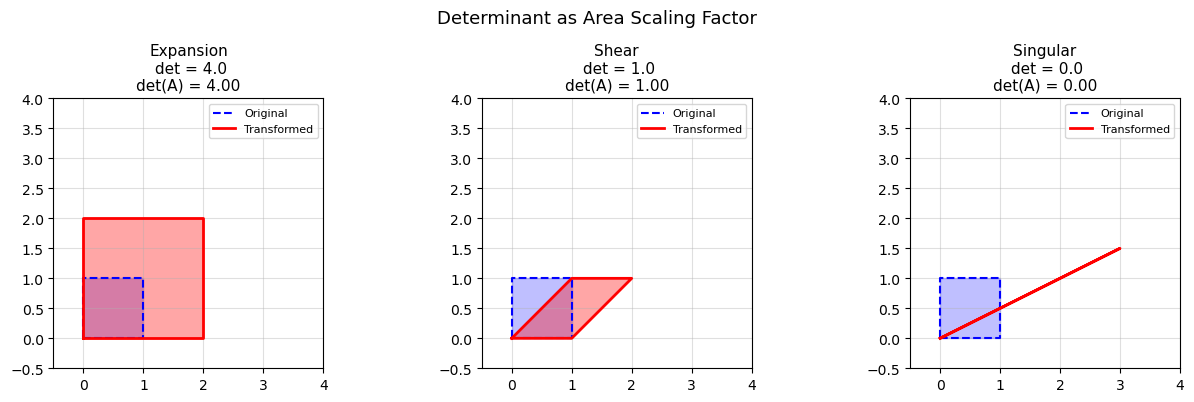

=== det(A) == product of eigenvalues ===
Expansion     det=4.0000  prod(λ)=4.0000  match=True
Shear         det=1.0000  prod(λ)=1.0000  match=True
Singular      det=0.0000  prod(λ)=0.0000  match=True


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection

# Unit square corners
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Three transformations with different determinants
transforms = {
    'Expansion\n det = 4.0': np.array([[2., 0.], [0., 2.]]),
    'Shear\n det = 1.0':     np.array([[1., 1.], [0., 1.]]),
    'Singular\n det = 0.0':  np.array([[1., 2.], [0.5, 1.]]),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

for ax, (label, M) in zip(axes, transforms.items()):
    original = square.T          # (4,2)
    transformed = (M @ square).T # (4,2)
    det = np.linalg.det(M)

    poly_orig = Polygon(original, closed=True, alpha=0.25, color='blue')
    poly_tran = Polygon(transformed, closed=True, alpha=0.35, color='red')
    ax.add_patch(poly_orig)
    ax.add_patch(poly_tran)
    ax.plot(*np.vstack([original, original[0]]).T, 'b--', lw=1.5, label='Original')
    ax.plot(*np.vstack([transformed, transformed[0]]).T, 'r-', lw=2, label='Transformed')
    ax.set_xlim(-0.5, 4); ax.set_ylim(-0.5, 4)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.4)
    ax.set_title(f'{label}\ndet(A) = {det:.2f}', fontsize=11)
    ax.legend(fontsize=8)

plt.suptitle('Determinant as Area Scaling Factor', fontsize=13)
plt.tight_layout()
plt.show()

# det == product of eigenvalues
print("=== det(A) == product of eigenvalues ===")
for label, M in transforms.items():
    d = np.linalg.det(M)
    eig_prod = np.prod(np.linalg.eigvals(M))
    print(f"{label.split(chr(10))[0]:12s}  det={d:.4f}  prod(λ)={eig_prod.real:.4f}  match={np.isclose(d, eig_prod.real)}")

---
# 5. Eigenvalues & Eigendecomposition

## 5.1 Eigenvalues and Eigenvectors

Let $A \in \mathbb{R}^{n \times n}$. A non-zero vector $\mathbf{v} \in \mathbb{R}^n$ is an **eigenvector** of $A$ with corresponding **eigenvalue** $\lambda \in \mathbb{R}$ if:

$$
A\mathbf{v} = \lambda \mathbf{v}
$$

Geometrically: eigenvectors are the **directions that the linear map does not rotate** — it only stretches or flips them by the factor $\lambda$.

To find eigenvalues, we solve the **characteristic equation**:
$$\det(A - \lambda I) = 0$$

This gives a degree-$n$ polynomial whose roots are the eigenvalues.

> **ML Bridge:** Eigenvalues and eigenvectors are used in PCA, spectral clustering, graph Laplacians, and the analysis of gradient descent convergence in quadratic loss landscapes.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

A = np.array([[3., 1.],
              [0., 2.]])

eigenvalues, eigenvectors = np.linalg.eig(A)

print("Matrix A:")
print(A)
print(f"\nEigenvalues:  {eigenvalues}")
print("Eigenvectors (each COLUMN is one eigenvector):")
print(eigenvectors)

# Verification: Av = λv
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    v   = eigenvectors[:, i]
    print(f"\nλ={lam:.1f}  Av={A @ v}  λv={lam * v}  match={np.allclose(A @ v, lam * v)}")

# Geometric visualization
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
colors = ['#E63946', '#457B9D']

for i, ax in enumerate(axes):
    v   = eigenvectors[:, i]
    Av  = A @ v
    lam = eigenvalues[i]

    ax.axhline(0, color='k', lw=0.8); ax.axvline(0, color='k', lw=0.8)
    ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
              color=colors[i], width=0.015, label=f'v (eigenvector)')
    ax.quiver(0, 0, Av[0], Av[1], angles='xy', scale_units='xy', scale=1,
              color=colors[i], alpha=0.4, width=0.015, label=f'Av = {lam:.1f}·v')
    ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
    ax.set_aspect('equal'); ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)
    ax.set_title(f'Eigenvector {i+1}: λ = {lam:.1f}', fontsize=11)

plt.suptitle('Eigenvectors: directions preserved by the linear map', fontsize=12)
plt.tight_layout()
plt.show()

## 5.2 Eigendecomposition

If $A \in \mathbb{R}^{n \times n}$ has $n$ linearly independent eigenvectors $\mathbf{v}_1, \dots, \mathbf{v}_n$ with eigenvalues $\lambda_1, \dots, \lambda_n$, then $A$ can be **diagonalized**:

$$
\boxed{A = P D P^{-1}}
$$

where:
- $P = [\mathbf{v}_1 \mid \mathbf{v}_2 \mid \dots \mid \mathbf{v}_n]$ — columns are eigenvectors
- $D = \text{diag}(\lambda_1, \dots, \lambda_n)$ — diagonal matrix of eigenvalues

**Why diagonalization is powerful:** powers of $A$ become trivial:
$$A^k = P D^k P^{-1}$$
and $D^k = \text{diag}(\lambda_1^k, \dots, \lambda_n^k)$.

**Special case — Symmetric matrices (Spectral Theorem):**
If $A = A^\top$, then:
- All eigenvalues are **real**
- Eigenvectors are **orthogonal**: $P^\top = P^{-1}$
- So $A = Q \Lambda Q^\top$ where $Q$ is orthogonal

Covariance matrices are always symmetric → this theorem applies directly to PCA.

> **ML Bridge:** PCA finds the eigendecomposition of the data covariance matrix $\Sigma = \frac{1}{N} X^\top X$. The eigenvectors are the **principal components** (directions of maximum variance); the eigenvalues tell you **how much variance** each direction explains.

In [ ]:
import numpy as np

# --- Eigendecomposition: A = P D P^{-1} ---
A = np.array([[4., 1.],
              [2., 3.]])

eigenvalues, P = np.linalg.eig(A)
D = np.diag(eigenvalues)
P_inv = np.linalg.inv(P)

A_reconstructed = P @ D @ P_inv

print("=== Eigendecomposition A = P D P^{-1} ===")
print(f"Eigenvalues: {eigenvalues}")
print(f"\nD (diagonal):\n{np.round(D, 4)}")
print(f"\nP (eigenvectors as columns):\n{np.round(P, 4)}")
print(f"\nP @ D @ P_inv (reconstructed A):\n{np.round(A_reconstructed, 4)}")
print(f"\nReconstruction matches original A: {np.allclose(A, A_reconstructed)}")

print()

# --- Symmetric matrix: Spectral Theorem ---
S = np.array([[4., 2.],
              [2., 3.]])  # symmetric by construction

# np.linalg.eigh is faster and guaranteed real for symmetric matrices
lam, Q = np.linalg.eigh(S)

print("=== Spectral Theorem: S = Q Λ Q^T  (S symmetric) ===")
print(f"Eigenvalues (all real): {lam}")
print(f"Q orthogonal? Q^T Q = I: {np.allclose(Q.T @ Q, np.eye(2))}")
print(f"Reconstruction S = Q Λ Q^T matches: {np.allclose(S, Q @ np.diag(lam) @ Q.T)}")

print()

# --- Powers of A via eigendecomposition ---
k = 5
Ak_direct = np.linalg.matrix_power(A, k)
Ak_eigen  = P @ np.diag(eigenvalues**k) @ P_inv

print(f"=== A^{k} via eigendecomposition ===")
print(f"Direct:  \n{np.round(Ak_direct, 2)}")
print(f"Via PDP^-1: \n{np.round(Ak_eigen.real, 2)}")
print(f"Match: {np.allclose(Ak_direct, Ak_eigen.real)}")

## 5.3 Summary & What Comes Next

| Concept | Key formula | ML use |
|---|---|---|
| Eigenvalue equation | $A\mathbf{v} = \lambda\mathbf{v}$ | Defines principal directions |
| Eigendecomposition | $A = PDP^{-1}$ | Matrix powers, diagonalization |
| Spectral Theorem | $A = Q\Lambda Q^\top$ (symmetric) | PCA, spectral clustering |
| det = product of λ | $\det(A) = \prod_i \lambda_i$ | Invertibility, volume scaling |
| trace = sum of λ | $\text{tr}(A) = \sum_i \lambda_i$ | Total variance in PCA |

---

**➡️ Continue in `PCA.ipynb`:**
The next notebook builds directly on eigendecomposition to develop:
1. **Projection** — orthogonal projection onto subspaces
2. **PCA** — finding the directions of maximum variance via eigendecomposition of the covariance matrix
3. **SVD** — the more general decomposition that powers PCA in practice and connects to the geometry of linear maps